# 1. eda for ieee data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path


sys.path.append(str(Path.cwd().parent))


plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')


In [11]:
from src.data.load import load_ieee

df = load_ieee()
df.head()

正在读取 train_transaction.csv ...
正在读取 train_identity.csv ...
正在合并 ...
合并完成：590,540 行，434 列
欺诈比例：3.499%


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [12]:
print("=== 数据形状 ===")
print(f"行数：{df.shape[0]:,}")
print(f"列数：{df.shape[1]}")

print("\n=== 列类型分布 ===")
print(df.dtypes.value_counts())

print("\n=== 目标变量分布 ===")
fraud_counts = df['isFraud'].value_counts()
print(f"正常交易：{fraud_counts[0]:,}  ({fraud_counts[0]/len(df)*100:.2f}%)")
print(f"欺诈交易：{fraud_counts[1]:,}  ({fraud_counts[1]/len(df)*100:.2f}%)")

print("\n=== 缺失值最严重的20列 ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'缺失数量': missing, '缺失比例%': missing_pct})
print(missing_df[missing_df['缺失数量'] > 0].sort_values('缺失比例%', ascending=False).head(20))

=== 数据形状 ===
行数：590,540
列数：434

=== 列类型分布 ===
float64    399
object      31
int64        4
Name: count, dtype: int64

=== 目标变量分布 ===
正常交易：569,877  (96.50%)
欺诈交易：20,663  (3.50%)

=== 缺失值最严重的20列 ===
         缺失数量  缺失比例%
id_24  585793  99.20
id_07  585385  99.13
id_25  585408  99.13
id_08  585385  99.13
id_26  585377  99.13
id_21  585381  99.13
id_23  585371  99.12
id_22  585371  99.12
id_27  585371  99.12
dist2  552913  93.63
D7     551623  93.41
id_18  545427  92.36
D13    528588  89.51
D14    528353  89.47
D12    525823  89.04
id_04  524216  88.77
id_03  524216  88.77
D6     517353  87.61
id_33  517251  87.59
id_10  515614  87.31


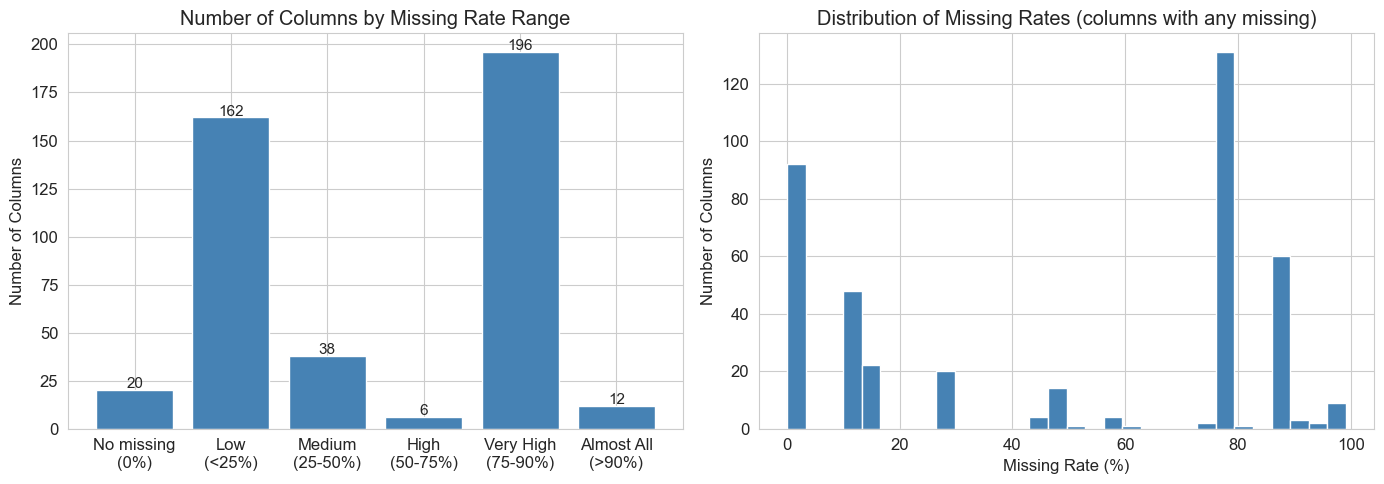

Columns with >90% missing:  12
Columns with >50% missing:  214
Columns with no missing:    20


In [6]:
import warnings
warnings.filterwarnings('ignore')

missing_pct = (df.isnull().sum() / len(df) * 100)

counts = []
counts.append((missing_pct == 0).sum())
counts.append(((missing_pct > 0) & (missing_pct <= 25)).sum())
counts.append(((missing_pct > 25) & (missing_pct <= 50)).sum())
counts.append(((missing_pct > 50) & (missing_pct <= 75)).sum())
counts.append(((missing_pct > 75) & (missing_pct <= 90)).sum())
counts.append((missing_pct > 90).sum())
labels = ['No missing\n(0%)', 'Low\n(<25%)', 'Medium\n(25-50%)', 
          'High\n(50-75%)', 'Very High\n(75-90%)', 'Almost All\n(>90%)']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(labels, counts, color='steelblue', edgecolor='white')
ax1.set_title('Number of Columns by Missing Rate Range')
ax1.set_ylabel('Number of Columns')
for i, v in enumerate(counts):
    ax1.text(i, v + 1, str(v), ha='center', fontsize=11)

missing_pct[missing_pct > 0].hist(bins=30, ax=ax2, color='steelblue', edgecolor='white')
ax2.set_title('Distribution of Missing Rates (columns with any missing)')
ax2.set_xlabel('Missing Rate (%)')
ax2.set_ylabel('Number of Columns')

plt.tight_layout()
plt.show()

print(f"Columns with >90% missing:  {(missing_pct > 90).sum()}")
print(f"Columns with >50% missing:  {(missing_pct > 50).sum()}")
print(f"Columns with no missing:    {(missing_pct == 0).sum()}")

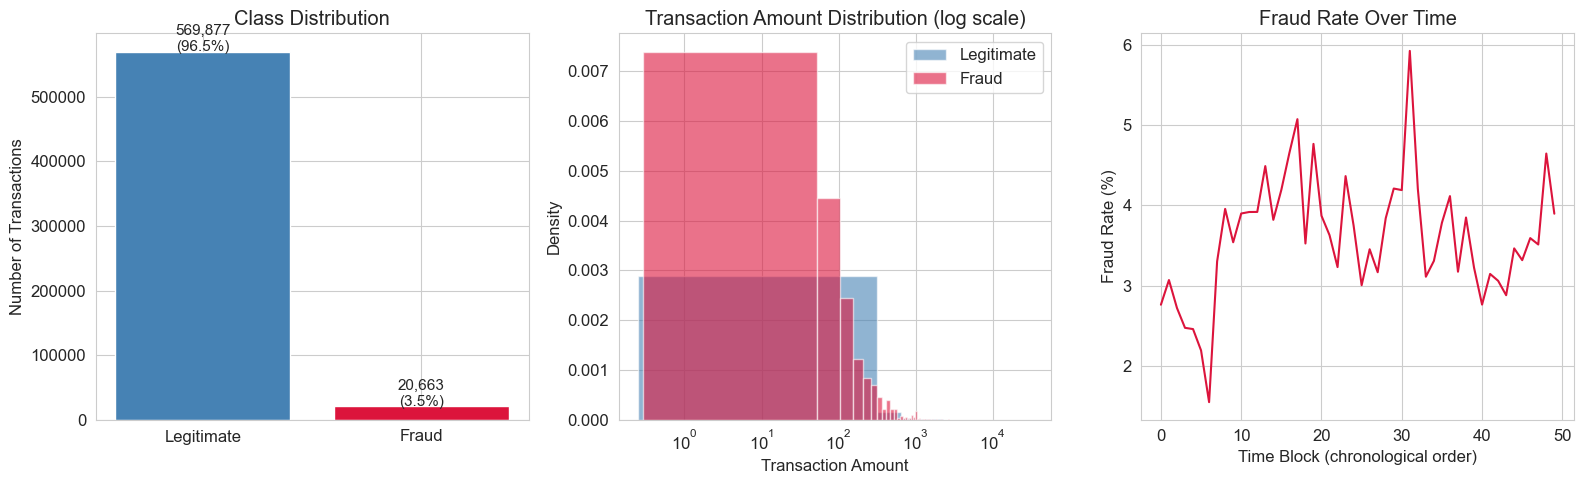

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 左图：class imbalance
fraud_counts = df['isFraud'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values, 
            color=['steelblue', 'crimson'], edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                 ha='center', fontsize=11)

# 中图：交易金额分布（log scale）
axes[1].hist(df[df['isFraud']==0]['TransactionAmt'], 
             bins=100, alpha=0.6, color='steelblue', label='Legitimate', density=True)
axes[1].hist(df[df['isFraud']==1]['TransactionAmt'], 
             bins=100, alpha=0.6, color='crimson', label='Fraud', density=True)
axes[1].set_xscale('log')
axes[1].set_title('Transaction Amount Distribution (log scale)')
axes[1].set_xlabel('Transaction Amount')
axes[1].set_ylabel('Density')
axes[1].legend()

# 右图：TransactionDT 上的欺诈率随时间变化
df['time_block'] = pd.cut(df['TransactionDT'], bins=50, labels=False)
fraud_rate_time = df.groupby('time_block')['isFraud'].mean() * 100
axes[2].plot(fraud_rate_time.index, fraud_rate_time.values, color='crimson', linewidth=1.5)
axes[2].set_title('Fraud Rate Over Time')
axes[2].set_xlabel('Time Block (chronological order)')
axes[2].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

- 左图： Class imbalance 非常明显，96.5% vs 3.5%，这直接说明为什么不能用 accuracy 作为评估指标。
- 中图： 欺诈交易集中在 $10-$100 区间，密度明显高于正常交易，而正常交易在高金额区间（$100-$10,000）有更长的尾巴。这是一个有用的信号。
- 右图： 欺诈率随时间明显波动，从早期的约 1.5% 一路升到后期的 5-6%，说明数据是非平稳的，这正好证明了为什么必须用 temporal split 而不能随机切分，报告里要专门提这一点。

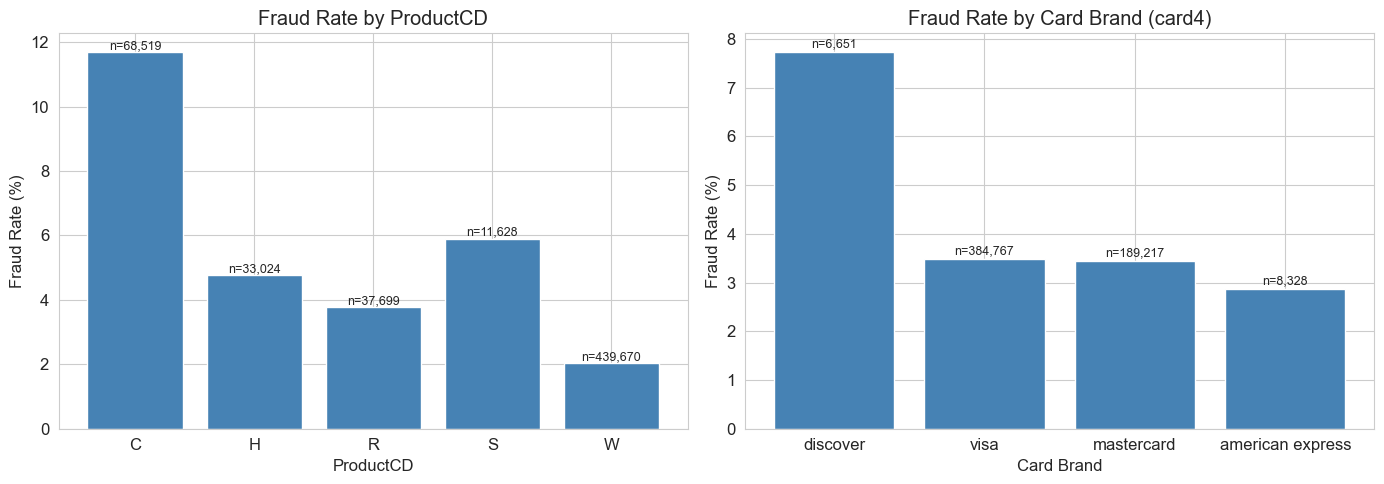

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：ProductCD 各类别的欺诈率
prod_fraud = df.groupby('ProductCD')['isFraud'].agg(['mean', 'count']).reset_index()
prod_fraud['mean'] = prod_fraud['mean'] * 100
bars = axes[0].bar(prod_fraud['ProductCD'], prod_fraud['mean'], 
                   color='steelblue', edgecolor='white')
axes[0].set_title('Fraud Rate by ProductCD')
axes[0].set_xlabel('ProductCD')
axes[0].set_ylabel('Fraud Rate (%)')
for bar, count in zip(bars, prod_fraud['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, 
                 bar.get_height() + 0.1,
                 f'n={count:,}', ha='center', fontsize=9)

# 右图：card4（卡品牌）的欺诈率
card4_fraud = df.groupby('card4')['isFraud'].agg(['mean', 'count']).reset_index()
card4_fraud = card4_fraud.dropna().sort_values('mean', ascending=False)
card4_fraud['mean'] = card4_fraud['mean'] * 100
bars2 = axes[1].bar(card4_fraud['card4'], card4_fraud['mean'],
                    color='steelblue', edgecolor='white')
axes[1].set_title('Fraud Rate by Card Brand (card4)')
axes[1].set_xlabel('Card Brand')
axes[1].set_ylabel('Fraud Rate (%)')
for bar, count in zip(bars2, card4_fraud['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'n={count:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

- 左图： ProductCD "C" 欺诈率高达 12%，是整体均值的 3 倍多，而最大量的 "W"（439,670笔）只有 2%。ProductCD 会是一个很强的特征。
- 右图： Discover 卡欺诈率 7.7%，接近 Visa/Mastercard 的两倍，但样本量只有 6,651，相对较小。

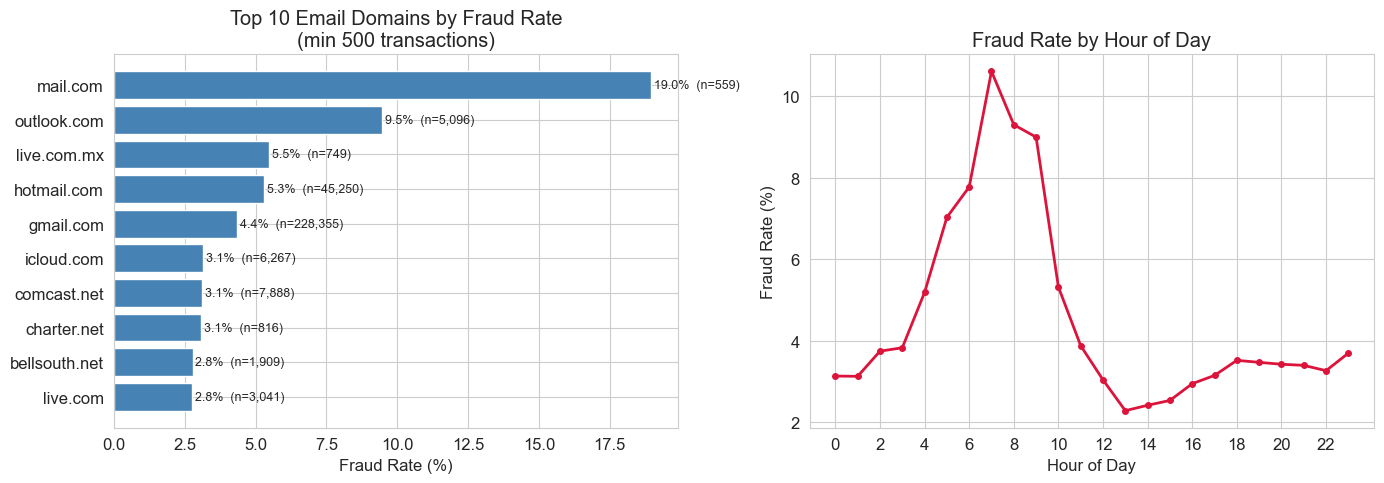

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：Top 10 高欺诈率邮件域名（P_emaildomain）
email_fraud = df.groupby('P_emaildomain')['isFraud'].agg(['mean', 'count'])
email_fraud = email_fraud[email_fraud['count'] >= 500].sort_values('mean', ascending=False).head(10)
email_fraud['mean'] = email_fraud['mean'] * 100

axes[0].barh(email_fraud.index, email_fraud['mean'], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 Email Domains by Fraud Rate\n(min 500 transactions)')
axes[0].set_xlabel('Fraud Rate (%)')
axes[0].invert_yaxis()
for i, (val, count) in enumerate(zip(email_fraud['mean'], email_fraud['count'])):
    axes[0].text(val + 0.1, i, f'{val:.1f}%  (n={count:,})', va='center', fontsize=9)

# 右图：一天中各小时的欺诈율
# TransactionDT 是从某基准点开始的秒数，取模得到小时
df['hour'] = (df['TransactionDT'] // 3600) % 24
hour_fraud = df.groupby('hour')['isFraud'].mean() * 100

axes[1].plot(hour_fraud.index, hour_fraud.values, 
             color='crimson', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

- 左图： mail.com 欺诈率高达 19%，outlook.com 9.5%，邮件域名是强信号，后面 feature engineering 里要用到
- 右图： 凌晨 6-8 点欺诈率骤升到 10%，中午 12-13 点降到最低 2.5%，这个时间规律很明显，hour 会是一个重要特征

### 结论

- 缺失值：208 列缺失率 >75%，需要设阈值丢弃
- Class imbalance：96.5% vs 3.5%，保留原始分布
- 时间非平稳：欺诈率随时间上升，必须 temporal split
- 强信号特征：ProductCD、card4、邮件域名、小时
- 金额分布：fraud 集中在低金额区间